# 02 · The SSP library and the PCA basis

Where the spectra come from, and how 831 wavelength bins become 50 numbers.

**Execution model — run end-to-end.** Everything here reads `data/` and takes a few
seconds. No merger tree and no galaxies: this rung is about the stellar population
library and the basis fitted to it, so it keeps working when the simulation output is
not mounted.

By the end you should be able to answer:

1. What is in the SSP library, and what "per unit formed mass" buys.
2. Why the library's own wavelength grid is a poor grid to fit on, and why R = 300.
3. What a weighting scheme is, which ones are allowed, and *why the forbidden ones
   fail silently*.
4. What a basis fit actually does, and why the mass term is part of the answer.
5. Why the far-UV reconstructs badly, and why no weighting scheme can rescue it.
6. Why 99.99 % of the variance is not 99.99 % of the accuracy — and why nobody should
   pick a component count from a variance threshold.
7. Which populations the basis handles well, as a function of age and metallicity.
8. Which of the two bases in this repository the rest of the project is using.

---

In [85]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()

from galspectra.pca.basis import SpectralBasis
from galspectra.pca.weighting import SCHEMES, REFUSED_SCHEMES, build_weights
from galspectra.pca.resample import (log_wavelength_grid, native_resolution,
                                     resampling_matrix, resolution_report)
from galspectra.pca.metrics import BandOperator, mag_difference, summarise_mmag
from galspectra.photometry.filter_sets import load_filter_set

grid   = np.load(PROJECT_ROOT / 'data' / 'sed_grid_bc03.npz', allow_pickle=True)
wave   = grid['wave']            # (831,) Angstrom
seds   = grid['seds']            # (1200, 831) flux per unit formed mass
params = grid['params']          # (1200, 2)
pname  = list(grid['param_names'])

age, logzsol = params[:, 0], params[:, 1]
ages_u, logz_u = np.unique(age), np.unique(logzsol)

print(f'library      : {seds.shape[0]:,} spectra x {seds.shape[1]} wavelength bins')
print(f'parameters   : {[str(x) for x in pname]}')
print(f'  ages       : {len(ages_u)} values, {ages_u.min() * 1e3:.1f} Myr - {ages_u.max():.1f} Gyr')
print(f'  logzsol    : {len(logz_u)} values, {logz_u.min():+.2f} to {logz_u.max():+.2f} '
      f'(Z/Zsun {10 ** logz_u.min():.3f} to {10 ** logz_u.max():.1f})')
print(f'wavelengths  : {wave.min():.0f} - {wave.max():.0f} A')
assert len(ages_u) * len(logz_u) == len(seds), 'the grid is not a full product'

# A broadband operator, reused from section 4.1 onwards. MegaCam rather than SDSS: it is
# the same ugriz system to within a few hundred Angstrom, and it ships in data/filters,
# so this notebook keeps working when the simulation tree is not mounted.
op_bb = BandOperator(wave, load_filter_set('megacam'), min_coverage=0.99)
print(f'broadband set: {", ".join(op_bb.names)}')

library      : 1,200 spectra x 831 wavelength bins
parameters   : ['tage', 'logzsol']
  ages       : 200 values, 0.1 Myr - 13.7 Gyr
  logzsol    : 6 values, -2.30 to +0.40 (Z/Zsun 0.005 to 2.5)
wavelengths  : 805 - 29950 A
broadband set: MegaCam_u, MegaCam_g, MegaCam_r, MegaCam_i, MegaCam_z


## 1. The library

1200 simple stellar populations: every combination of 200 ages and 6 metallicities, each
one the spectrum of a population that formed **in a single burst** and has been ageing
ever since.

The normalisation is the load-bearing part. Every row is flux **per unit formed stellar
mass** — not per surviving mass, not normalised to a band. That is what makes the central
identity of this project true:

$$L_{\rm gal}(\lambda) \;=\; \sum_i m_i \, S(\lambda;\, {\rm age}_i,\, Z_i)$$

A galaxy is the mass-weighted sum of simple populations. Everything downstream — the
basis, the coefficients, the composition in §4 — exists to keep that sum exact. §3 shows
what happens when a plausible-looking preprocessing step breaks it.

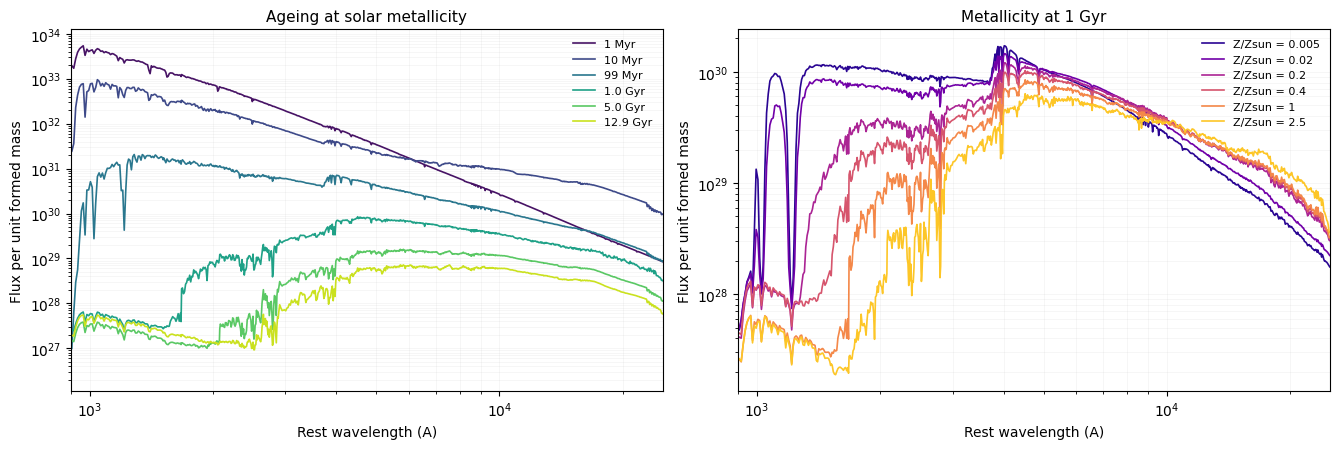

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))

# ── ageing at fixed metallicity ────────────────────────────────────────────
solar = np.isclose(logzsol, 0.0)
show_ages = [0.001, 0.01, 0.1, 1.0, 5.0, 13.0]
cmap = plt.cm.viridis(np.linspace(0.05, 0.92, len(show_ages)))
for c, t in zip(cmap, show_ages):
    j = np.flatnonzero(solar)[np.argmin(np.abs(age[solar] - t))]
    lbl = f'{age[j] * 1e3:.0f} Myr' if age[j] < 1 else f'{age[j]:.1f} Gyr'
    axes[0].plot(wave, seds[j], color=c, lw=1.2, label=lbl)
axes[0].set_title('Ageing at solar metallicity', fontsize=11)

# ── metallicity at fixed age ───────────────────────────────────────────────
target = 1.0
cmap = plt.cm.plasma(np.linspace(0.05, 0.88, len(logz_u)))
for c, lz in zip(cmap, logz_u):
    sel = np.isclose(logzsol, lz)
    j = np.flatnonzero(sel)[np.argmin(np.abs(age[sel] - target))]
    axes[1].plot(wave, seds[j], color=c, lw=1.2, label=f'Z/Zsun = {10 ** lz:.3g}')
axes[1].set_title(f'Metallicity at {target:.0f} Gyr', fontsize=11)

for ax in axes:
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(900, 25000)
    ax.set_xlabel('Rest wavelength (A)')
    ax.set_ylabel('Flux per unit formed mass')
    ax.legend(fontsize=8, frameon=False)
    ax.grid(alpha=0.2, which='both', lw=0.4)
fig.tight_layout(); plt.show()

---

## 2. The native grid, and why R = 300

The library is delivered on a **piecewise** wavelength grid — 10 Å in the UV, 20 Å across
the optical, then 50 and 100 Å into the near-infrared. Its resolving power
$R = \lambda/\Delta\lambda$ therefore varies by a factor of five across the range.

That matters because **a PCA weights every column equally**. Fitting on this grid hands
extra influence to the optical for no reason other than that the optical happens to be
sampled more finely. A grid of constant resolving power removes the accident: every decade
of wavelength then contributes the same number of columns.

native resolving power: min 80, median 250, max 498
  requested_R              300.0
  native_R_min             105.5
  native_R_median          248.5
  native_R_max             498.5
  fraction_oversampled     0.6954177897574124
  max_oversampling_factor  2.843601895734597
  interpolating            True


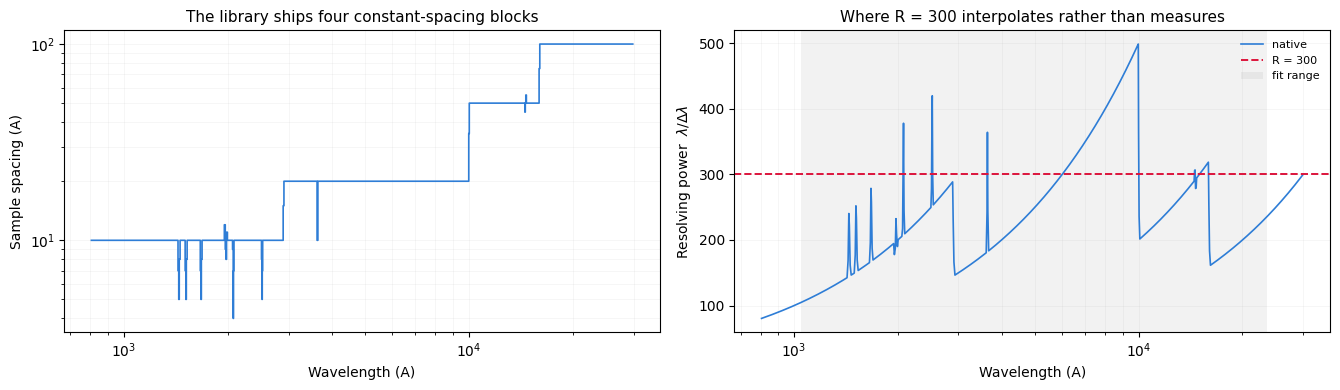

In [87]:
R_native = native_resolution(wave)
print(f'native resolving power: min {R_native.min():.0f}, '
      f'median {np.median(R_native):.0f}, max {R_native.max():.0f}')

# The requested range is the union requirement from documents/wavelength_requirements.md.
report = resolution_report(wave, 300, 1048.0, 23552.0)
for k, v in report.items():
    print(f'  {k:24s} {v}')

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.0))
axes[0].step(wave[:-1], np.diff(wave), where='post', color='#2E7DD6', lw=1.2)
axes[0].set_yscale('log'); axes[0].set_ylabel('Sample spacing (A)')
axes[0].set_title('The library ships four constant-spacing blocks', fontsize=11)

axes[1].plot(wave, R_native, color='#2E7DD6', lw=1.2, label='native')
axes[1].axhline(300, color='crimson', ls='--', lw=1.4, label='R = 300')
axes[1].axvspan(1048, 23552, color='grey', alpha=0.10, lw=0, label='fit range')
axes[1].set_ylabel('Resolving power  $\\lambda/\\Delta\\lambda$')
axes[1].set_title('Where R = 300 interpolates rather than measures', fontsize=11)
axes[1].legend(fontsize=8, frameon=False)
for ax in axes:
    ax.set_xscale('log'); ax.set_xlabel('Wavelength (A)')
    ax.grid(alpha=0.2, which='both', lw=0.4)
fig.tight_layout(); plt.show()

Roughly 70 % of the fitting range is *oversampled* at R = 300, by up to 2.8× in the far
UV. That is worth being blunt about: **resampling cannot create information.** Those extra
columns are a smooth interpolation of the library, not spectral detail the library
contains. It is legitimate — it makes the PCA's implicit metric uniform, and passbands far
wider than the sampling are unaffected — but it must be reported rather than assumed,
which is what `resolution_report()` is for.

So does the constant-R grid actually help? Refit on it and measure, rather than arguing.
The resampling is a fixed matrix applied to every spectrum, so it stays linear in flux;
`np.interp` would also be linear but is not flux-conserving, and every metric here is a
passband integral.

In [88]:
# NOTE the return order: (centres, edges). Swapping them silently yields a grid one bin
# short, and the error only surfaces as a shape mismatch two calls later.
centres, edges = log_wavelength_grid(1048.0, 23552.0, 300)
M_resample = resampling_matrix(wave, edges)      # fixed matrix -> linear in flux
seds_R300  = seds @ M_resample.T

paus = load_filter_set('paus_nb')                # 40 narrow bands, 100 A wide
print(f'resampled: {seds.shape[1]} native bins -> {centres.size} bins at R = 300')
print(f'evaluated through {len(paus)} PAUS narrow bands\n')

print(f'{"basis at N = 50":<24}{"bands":>7}{"SSP MAD":>12}{"p99":>10}')
print('-' * 53)
fits = {}
for label, w_, X_ in (('native, 831 bins', wave, seds),
                      ('R = 300 log, 934 bins', centres, seds_R300)):
    op = BandOperator(w_, paus, min_coverage=0.99)
    b  = SpectralBasis.fit(w_, X_, 50, weight_scheme='inverse_std')
    rec = b.reconstruct(b.transform(X_), np.ones(len(X_)))
    s = summarise_mmag(mag_difference(X_, rec, op))
    fits[label] = (np.median(s['mad']), np.median(s['p99']))
    print(f'{label:<24}{len(op):>7}{np.median(s["mad"]):>10.4f} mmag{np.median(s["p99"]):>9.2f}')
print(f'\nR = 300 is {fits["native, 831 bins"][0] / fits["R = 300 log, 934 bins"][0]:.2f}x '
      f'better in MAD at identical storage.')

resampled: 831 native bins -> 934 bins at R = 300
evaluated through 40 PAUS narrow bands

basis at N = 50           bands     SSP MAD       p99
-----------------------------------------------------
native, 831 bins             40    0.1364 mmag     6.75
R = 300 log, 934 bins        40    0.1002 mmag     4.63

R = 300 is 1.36x better in MAD at identical storage.


---

## 3. Weighting — and the one that fails silently

A PCA minimises squared error in whatever units you hand it. Flux spans many decades
across this library, so an unweighted fit spends its components on the bright red optical
and ignores the faint blue continuum entirely. A **weight** rescales the columns of the
design matrix and so chooses which wavelengths the fit works hardest to reproduce.

There is one hard rule, and it is architectural rather than aesthetic:

> A weight must be a fixed function of **wavelength alone** — shape `(N_wave,)`, never
> `(N_ssp,)`.

Anything that depends on the individual spectrum — its L2 norm, its value at 5500 Å, its
peak, its logarithm — destroys $L_{\rm gal} = \sum_i m_i S_i$. `build_weights` therefore
refuses four such schemes *by name*.

scheme                     min w       max w   dynamic range
------------------------------------------------------------
uniform                   1.0000        1.00               1
inverse_std               0.0064       65.95          10,256
inverse_rms               0.0062       72.78          11,816
inverse_mean              0.0055       99.67          18,187
piecewise (break x3)      0.0058       68.94          11,816


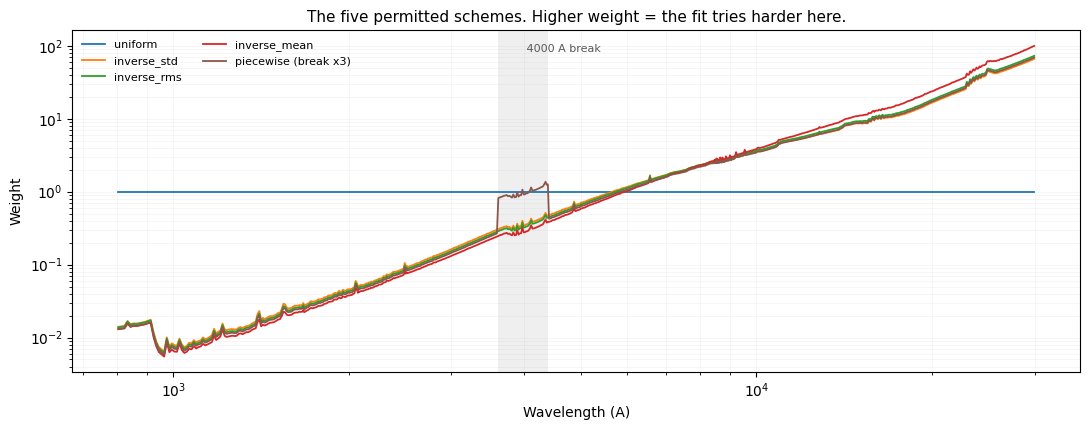

In [89]:
PIECEWISE = {'base': 'inverse_rms',
             'regions': [{'min': 3600.0, 'max': 4400.0, 'factor': 3.0}]}

fig, ax = plt.subplots(figsize=(11, 4.4))
colors = plt.cm.tab10(np.linspace(0, 0.5, len(SCHEMES)))
print(f'{"scheme":<22}{"min w":>10}{"max w":>12}{"dynamic range":>16}')
print('-' * 60)
for c, scheme in zip(colors, SCHEMES):
    kw = PIECEWISE if scheme == 'piecewise' else {}
    w, meta = build_weights(scheme, seds, wave, **kw)
    lbl = 'piecewise (break x3)' if scheme == 'piecewise' else scheme
    ax.plot(wave, w, color=c, lw=1.3, label=lbl)
    print(f'{lbl:<22}{w.min():>10.4f}{w.max():>12.2f}{w.max() / w.min():>16,.0f}')

ax.axvspan(3600, 4400, color='grey', alpha=0.12, lw=0)
ax.text(3980, ax.get_ylim()[1], ' 4000 A break', fontsize=8, va='top', color='0.35')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Wavelength (A)'); ax.set_ylabel('Weight')
ax.set_title('The five permitted schemes. Higher weight = the fit tries harder here.',
             fontsize=11)
ax.legend(fontsize=8, frameon=False, ncol=2)
ax.grid(alpha=0.2, which='both', lw=0.4)
fig.tight_layout(); plt.show()

### Why the refused schemes are refused

The refusal is not fussiness. Here is the failure, reproduced.

The critical detail is **where the composition happens**. If you reconstruct each SSP
individually and *then* sum, a per-spectrum normalisation looks completely fine — every
SSP comes back to a fraction of a percent. The pipeline does not do that. It accumulates
coefficients over the star-formation history, $C_k = \sum_i m_i c_{ik}$, and reconstructs
**once**. That is where a per-spectrum scale has nowhere to go.

This is worth dwelling on because it is what "silent" means: every per-SSP unit test
passes, and only the galaxies are wrong.

In [90]:
from sklearn.decomposition import PCA

for scheme in REFUSED_SCHEMES:
    try:
        build_weights(scheme, seds, wave)
        print(f'{scheme}: NOT REFUSED -- the guard has regressed')
    except ValueError as exc:
        print(f'{scheme:>6}  refused: {str(exc).splitlines()[1].strip()[:78]}...')

# A sparse star-formation history: 5% of the library, random masses.
rng = np.random.default_rng(0)
m = np.where(rng.random(len(seds)) < 0.05, rng.random(len(seds)), 0.0)
galaxy_true = m @ seds

def frac(a, b):
    return float(np.median(np.abs(a - b) / np.maximum(b, 1e-30)))

# ── safe: weights depend on wavelength only ────────────────────────────────
safe = SpectralBasis.fit(wave, seds, 50, weight_scheme='inverse_std')
c_safe = safe.transform(seds)
C, M = safe.compose(c_safe, m)                       # C = sum_i m_i c_i,  M = sum_i m_i
galaxy_safe = safe.reconstruct(C, M)

# ── unsafe: each spectrum divided by its own L2 norm ───────────────────────
nrm = np.linalg.norm(seds, axis=1, keepdims=True)
p = PCA(n_components=50).fit(seds / nrm)
c_l2 = p.transform(seds / nrm)
galaxy_l2 = p.mean_ + (m @ c_l2) @ p.components_     # no per-galaxy norm exists to restore

print(f'\n{"":36}{"safe":>12}{"L2-normalised":>16}')
print('-' * 64)
print(f'{"per-SSP reconstruction (fractional)":<36}'
      f'{frac(safe.reconstruct(c_safe, np.ones(len(seds))), seds):>12.2e}'
      f'{frac((c_l2 @ p.components_ + p.mean_) * nrm, seds):>16.2e}')
print(f'{"COMPOSED galaxy (fractional)":<36}'
      f'{frac(galaxy_safe, galaxy_true):>12.2e}{frac(galaxy_l2, galaxy_true):>16.2e}')
print(f'\nPer SSP the two are comparable. Composed, the L2 basis is '
      f'{frac(galaxy_l2, galaxy_true) / frac(galaxy_safe, galaxy_true):,.0f}x worse.')

    l2  refused: 'l2' divides each spectrum by its own L2 norm. That is a per-spectrum operatio...
 5500A  refused: '5500A' divides each spectrum by its own value at 5500 Å. Same failure mode as...
   log  refused: PCA on log(flux) is not linear in flux: exp(Σ log) is a product, not a sum, so...
  peak  refused: Normalising by each spectrum's peak is per-spectrum, therefore non-linear in f...

                                            safe   L2-normalised
----------------------------------------------------------------
per-SSP reconstruction (fractional)     2.79e-04        1.14e-03
COMPOSED galaxy (fractional)            2.60e-05        1.00e+00

Per SSP the two are comparable. Composed, the L2 basis is 38,456x worse.


---

## 4. Fitting a basis

`SpectralBasis.fit` does three things:

1. builds the weight vector and multiplies it into the library,
2. runs the PCA in that weighted space,
3. **divides the weights straight back out** of the mean and the components.

Step 3 is why the stored basis is a set of honest spectra in flux units rather than
spectra-in-weighted-units that only reconstruct if the caller remembers the weights.

The reconstruction carries the mass explicitly:

$$L(\lambda) \;=\; M\,\mu_{\rm eff}(\lambda) \;+\; \sum_k C_k B_k(\lambda),
\qquad C_k = \sum_i m_i c_{ik}, \quad M = \sum_i m_i$$

Both terms are linear in the $m_i$, so composition is exact *by construction* — not
approximately, not to within the truncation error. The honest storage cost is therefore
$N_{\rm pc} + 1$ numbers per galaxy: coefficients alone cannot reconstruct anything,
because the mean term has to be scaled by the formed mass.

  n_components             50
  n_wave                   831
  wave_min                 805.0
  wave_max                 29950.0
  weighting                inverse_std
  bytes_per_galaxy_f32     204
  cumulative_variance      0.9999999614257161


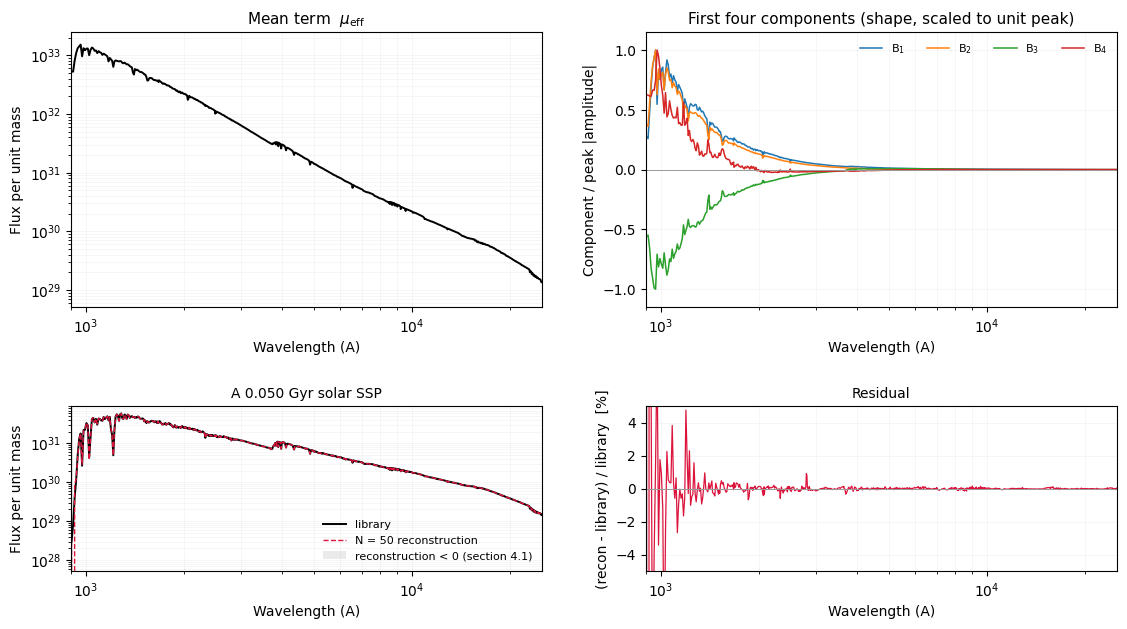

this SSP: reconstruction is negative in 3 of 831 bins, all below 915 A


In [91]:
basis = SpectralBasis.fit(wave, seds, 50, weight_scheme='inverse_std')
for k, v in basis.summary().items():
    print(f'  {k:24s} {v}')

fig = plt.figure(figsize=(13.5, 7.0))
gs = fig.add_gridspec(2, 2, height_ratios=[2.0, 1.2], hspace=0.45, wspace=0.22)

ax_mu = fig.add_subplot(gs[0, 0])
ax_mu.plot(wave, basis.mu_eff, color='black', lw=1.4)
ax_mu.set_yscale('log'); ax_mu.set_title('Mean term  $\\mu_{\\rm eff}$', fontsize=11)
ax_mu.set_ylabel('Flux per unit mass')

# Components are plotted scaled to unit peak, on a linear axis. They span many decades
# in absolute terms, and a symlog axis turns that into a ladder of tick labels that
# hides the only thing worth seeing here: the shape of each mode.
ax_b = fig.add_subplot(gs[0, 1])
for k, c in zip(range(4), plt.cm.tab10(np.linspace(0, 0.35, 4))):
    Bk = basis.components[k]
    ax_b.plot(wave, Bk / np.abs(Bk).max(), color=c, lw=1.1, label=f'B$_{k + 1}$')
ax_b.axhline(0, color='0.6', lw=0.7); ax_b.set_ylim(-1.15, 1.15)
ax_b.set_ylabel('Component / peak |amplitude|')
ax_b.set_title('First four components (shape, scaled to unit peak)', fontsize=11)
ax_b.legend(fontsize=8, frameon=False, ncol=4)

# One reconstruction, and the defect section 4.1 explains, shown rather than hidden.
sed_age = 0.05   #Gyr
j = int(np.flatnonzero(solar)[np.argmin(np.abs(age[solar] - sed_age))])
rec = basis.reconstruct(basis.transform(seds[j])[0], 1.0)
neg = rec <= 0
bad_hi = wave[neg].max() if neg.any() else None

ax_s = fig.add_subplot(gs[1, 0])
ax_s.plot(wave, seds[j], color='black', lw=1.4, label='library')
ax_s.plot(wave, rec, color='crimson', lw=1.0, ls='--', label='N = 50 reconstruction')
ax_s.set_yscale('log'); ax_s.set_ylabel('Flux per unit mass')
ax_s.set_title('A {:.3f} Gyr solar SSP'.format(sed_age), fontsize=10)
ax_s.set_ylim(bottom=np.percentile(seds[j][seds[j] > 0], 1) * 0.2)

ax_r = fig.add_subplot(gs[1, 1])
with np.errstate(divide='ignore', invalid='ignore'):
    ax_r.plot(wave, 100 * (rec - seds[j]) / seds[j], color='crimson', lw=0.9)
ax_r.axhline(0, color='0.6', lw=0.7); ax_r.set_ylim(-5, 5)
ax_r.set_ylabel('(recon - library) / library  [%]')
ax_r.set_title('Residual', fontsize=10)

# The shaded band is labelled through the legend rather than with text on the axes:
# it lands on top of the very data it is pointing at otherwise.
if bad_hi is not None:
    ax_s.axvspan(wave.min(), bad_hi, color='grey', alpha=0.16, lw=0,
                 label='reconstruction < 0 (section 4.1)')
    ax_r.axvspan(wave.min(), bad_hi, color='grey', alpha=0.16, lw=0)
ax_s.legend(fontsize=8, frameon=False, loc='lower right')

for ax in (ax_mu, ax_b, ax_s, ax_r):
    ax.set_xscale('log'); ax.set_xlim(900, 25000)
    ax.set_xlabel('Wavelength (A)'); ax.grid(alpha=0.2, which='both', lw=0.4)
plt.show()

print(f'this SSP: reconstruction is negative in {neg.sum()} of {neg.size} bins, '
      f'all below {bad_hi:.0f} A')

In [92]:
# The claim the whole architecture rests on, asserted rather than printed.
sfh_bins = rng.choice(len(seds), size=13, replace=False)      # a 13-bin SFH
masses   = rng.random(13) * 1e9

C, M = basis.compose(basis.transform(seds[sfh_bins]), masses)
composed  = basis.reconstruct(C, M)
summed    = sum(mi * basis.reconstruct(basis.transform(s)[0], 1.0)
                for mi, s in zip(masses, seds[sfh_bins]))

rel = np.max(np.abs(composed - summed) / np.maximum(np.abs(summed), 1e-30))
assert rel < 1e-10, f'composition is not exact: {rel:.2e}'
print(f'compose-then-reconstruct vs reconstruct-then-sum: max relative diff {rel:.2e}')

# And the failure mode the design prevents: dropping the mass on the mean term.
broken = basis.reconstruct_without_mass(C)
print(f'with the mean term unscaled by mass:               '
      f'{np.median(np.abs(broken - composed) / np.abs(composed)):.2e} fractional error')
print(f'\nstorage: {basis.n_components} coefficients + 1 mass = '
      f'{basis.bytes_per_galaxy(np.float32)} bytes per galaxy (float32)')

compose-then-reconstruct vs reconstruct-then-sum: max relative diff 2.78e-15
with the mean term unscaled by mass:               1.66e+00 fractional error

storage: 50 coefficients + 1 mass = 204 bytes per galaxy (float32)


---

---

## 4.1 Why the far-UV reconstructs badly

The shaded band above is not a rendering artefact and it is not a bug. It has a single
cause, and it is worth understanding because it constrains what this whole approach can
do.

**The library spans five orders of magnitude in the UV.** A population younger than
10 Myr is full of hot massive stars and blazes below 2800 A. The same mass of stars at
10 Gyr has none of them left. Both live in the same columns of the design matrix.

**PCA minimises absolute error.** So the residual it leaves in the UV is set by the bright
young populations, which is where the variance is — and that residual is then comparable
to, or larger than, the *entire flux* of an old population at the same wavelengths.

age               n   median UV flux  UV frac error   any UV bin < 0
--------------------------------------------------------------------
< 10 Myr        468         6.60e+32          0.000               0 %
10-100 Myr      234         5.15e+31          0.001              40 %
0.1-1 Gyr       228         1.78e+30          0.011             100 %
1-5 Gyr         168         1.36e+28          0.642             100 %
> 5 Gyr         102         4.76e+27          2.488             100 %

At N = 50, over 805-2800 A:
  typical absolute residual                 2.524e+28
  median flux of a population older than 5 Gyr  4.758e+27
  -> the residual is 5.3x that entire flux

correlation of log10(UV flux) with log10(UV fractional error): r = -0.989


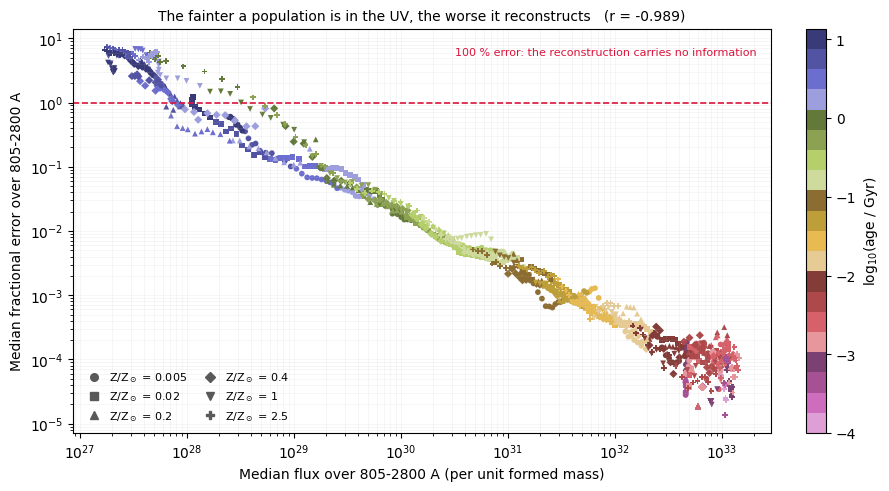

In [93]:
UV   = (wave >= 805) & (wave < 2800)
OPT  = (wave >= 3646) & (wave < 9000)

rec50 = basis.reconstruct(basis.transform(seds), np.ones(len(seds)))
fracerr = np.abs(rec50 - seds) / np.maximum(seds, 1e-30)

print(f'{"age":<14}{"n":>5}{"median UV flux":>17}{"UV frac error":>15}{"any UV bin < 0":>17}')
print('-' * 68)
AGE_BINS = [(0, 0.01, '< 10 Myr'), (0.01, 0.1, '10-100 Myr'), (0.1, 1, '0.1-1 Gyr'),
            (1, 5, '1-5 Gyr'), (5, 14, '> 5 Gyr')]
for lo, hi, lab in AGE_BINS:
    m = (age >= lo) & (age < hi)
    print(f'{lab:<14}{m.sum():>5}{np.median(seds[m][:, UV]):>17.2e}'
          f'{np.median(fracerr[m][:, UV]):>15.3f}'
          f'{np.mean((rec50[m][:, UV] < 0).any(axis=1)) * 100:>16.0f} %')

old = age > 5
resid_uv = np.median(np.abs(rec50 - seds)[:, UV])
flux_old = np.median(seds[old][:, UV])
print(f'\nAt N = {basis.n_components}, over 805-2800 A:')
print(f'  typical absolute residual                 {resid_uv:.3e}')
print(f'  median flux of a population older than 5 Gyr  {flux_old:.3e}')
print(f'  -> the residual is {resid_uv / flux_old:.1f}x that entire flux')

# The mechanism as a measurement rather than a story.
uv_err  = np.median(fracerr[:, UV], axis=1)
uv_flux = np.median(seds[:, UV], axis=1)
ok = uv_err > 0
r = np.corrcoef(np.log10(uv_flux[ok]), np.log10(uv_err[ok]))[0, 1]
print(f'\ncorrelation of log10(UV flux) with log10(UV fractional error): r = {r:+.3f}')

# Colour carries age; the marker carries metallicity. Six metallicities is few enough
# for shape to be readable, and it separates the two parameters cleanly -- one colour
# scale cannot show both. All six calls share a single Normalize so the colour bar
# applies to every series rather than only the last one drawn.
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize

Z_MARKERS = ['o', 's', '^', 'D', 'v', 'P']
CMAP      = 'tab20b_r'
norm_age  = Normalize(vmin=np.log10(age[ok]).min(), vmax=np.log10(age[ok]).max())

fig, ax = plt.subplots(figsize=(8.8, 4.8), layout='constrained')
for z, marker in zip(logz_u, Z_MARKERS):
    m = ok & np.isclose(logzsol, z)
    sc = ax.scatter(uv_flux[m], uv_err[m], c=np.log10(age[m]), s=17, marker=marker,
                    cmap=CMAP, norm=norm_age, linewidths=0)
ax.axhline(1.0, color='crimson', ls='--', lw=1.2)
# Anchored in axes coordinates: placed in data coordinates on a log axis this string is
# wider than the axis and constrained_layout collapses the plot trying to fit it.
ax.text(0.98, 0.955, '100 % error: the reconstruction carries no information',
        transform=ax.transAxes, fontsize=8, color='crimson', va='top', ha='right')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Median flux over 805-2800 A (per unit formed mass)')
ax.set_ylabel('Median fractional error over 805-2800 A')
ax.set_title(f'The fainter a population is in the UV, the worse it reconstructs   '
             f'(r = {r:+.3f})', fontsize=10)
fig.colorbar(sc, ax=ax, label='log$_{10}$(age / Gyr)')
# Proxy handles in neutral grey: the legend is about shape alone, and colouring them
# would imply a metallicity-colour mapping that does not exist.
ax.legend(handles=[Line2D([], [], marker=mk, ls='none', color='0.35', markersize=5.5,
                          label=f'Z/Z$_\\odot$ = {10 ** z:g}')
                   for z, mk in zip(logz_u, Z_MARKERS)],
          fontsize=8, frameon=False, loc='lower left', ncol=2,
          handletextpad=0.4, columnspacing=1.0)
ax.grid(alpha=0.2, which='both', lw=0.4)
plt.show()

So: can this be bought off, either with a weighting scheme or with more components?

The first is the interesting question, because §3 established that a weight must be a
function of **wavelength alone**. That constraint has a consequence here. At 1500 Å one
number has to serve a young population and an old one $10^5$ times fainter — it cannot
give the faint one more attention without also giving the bright one more.

In [94]:
def uv_boost(factor):
    return {'base': 'inverse_rms',
            'regions': [{'min': 805.0, 'max': 2800.0, 'factor': factor}]}

trials = [('uniform', 'uniform', None), ('inverse_std', 'inverse_std', None),
          ('inverse_rms', 'inverse_rms', None)]
trials += [(f'piecewise, UV x{f:g}', 'piecewise', uv_boost(f)) for f in (10, 100, 1000)]

print(f'{"weighting":<24}{"UV error (old)":>16}{"ugriz (mmag)":>14}{"negative bins":>16}')
print('-' * 70)
for label, scheme, kw in trials:
    bb = SpectralBasis.fit(wave, seds, 50, weight_scheme=scheme, weight_kwargs=kw)
    rr = bb.reconstruct(bb.transform(seds), np.ones(len(seds)))
    fr = np.abs(rr - seds) / np.maximum(seds, 1e-30)
    dm = np.nanmedian(np.abs(mag_difference(seds, rr, op_bb)))
    print(f'{label:<24}{np.median(fr[old][:, UV]):>16.3f}{dm:>14.4f}'
          f'{(rr < 0).mean() * 100:>15.2f} %')

print(f'\n{"N":>5}{"UV error (old)":>17}{"optical (old)":>16}{"negative bins":>16}')
print('-' * 55)
deep = SpectralBasis.fit(wave, seds, 150, weight_scheme='inverse_std')
for n in (25, 50, 100, 150):
    b_n = deep.truncate(n)
    r_n = b_n.reconstruct(b_n.transform(seds), np.ones(len(seds)))
    f_n = np.abs(r_n - seds) / np.maximum(seds, 1e-30)
    print(f'{n:>5}{np.median(f_n[old][:, UV]):>17.3f}'
          f'{np.median(f_n[old][:, OPT]):>16.6f}{(r_n < 0).mean() * 100:>15.2f} %')

weighting                 UV error (old)  ugriz (mmag)   negative bins
----------------------------------------------------------------------
uniform                            0.614        0.4947           1.12 %
inverse_std                        2.488        0.0445           1.92 %
inverse_rms                        2.615        0.0449           1.94 %
piecewise, UV x10                  0.908        0.2074           1.60 %
piecewise, UV x100                 0.397        1.1169           1.19 %
piecewise, UV x1000                0.456        5.3855           1.76 %

    N   UV error (old)   optical (old)   negative bins
-------------------------------------------------------
   25           15.589        0.012675           2.91 %
   50            2.488        0.003500           1.92 %
  100            0.324        0.000610           0.94 %
  150            0.087        0.000145           0.14 %


Both answers are informative.

**Weighting cannot fix it.** Pushing the UV weight up by 100x is the best this scheme can
do — and it still leaves 40 % error there, while costing 24x in broadband accuracy. Push it
to 1000x and the UV gets *worse again* while the photometry degrades by another factor of
five. There is no setting that is good in both places, because a diagonal weight has one
number per wavelength and the problem is a spread *within* each wavelength.

Note also that `inverse_std` — the scheme this project uses, and the best of them by every
photometric measure — is the **worst** in the UV, four times worse than `uniform`. It
down-weights the UV by 860x relative to the near-IR precisely *because* that is where the
library varies most.

**More components do fix it, slowly.** The far-UV error falls from 2.5 at N = 50 to 0.09 at
N = 150 — so this is a cost, not a wall, and the price is three times the storage for a
region that contributes nothing to rest-frame optical photometry.

That is the honest summary: **the basis is accurate where the library is bright.** The
negative fluxes of §6 are not a separate defect; they are the same phenomenon seen from a
different angle.

## 5. Explained variance is not an error budget

The tempting way to choose a component count is to keep 99.9-something percent of the
variance. Do that here and you stop at about 15 components.

Fit once at N = 100 and truncate: PCA components are nested, so a truncated basis is
*exactly* the basis you would get by refitting at that count. Then measure what actually
matters — the error in the passbands the science uses.

    N   cumulative variance   SSP MAD (mmag)   p99 (mmag)
---------------------------------------------------------
    5           0.999100927           16.449       334.05
   10           0.999921438            6.979       223.28
   15           0.999984293            3.027       115.61   <- "99.99% of the variance"
   20           0.999995233            1.866        70.40
   25           0.999998224            1.218        34.96
   30           0.999999381            0.696        22.27
   40           0.999999865            0.282        10.43
   50           0.999999961            0.136         6.75
   60           0.999999989            0.083         3.43
   75           0.999999997            0.038         1.84
  100           1.000000000            0.011         0.86


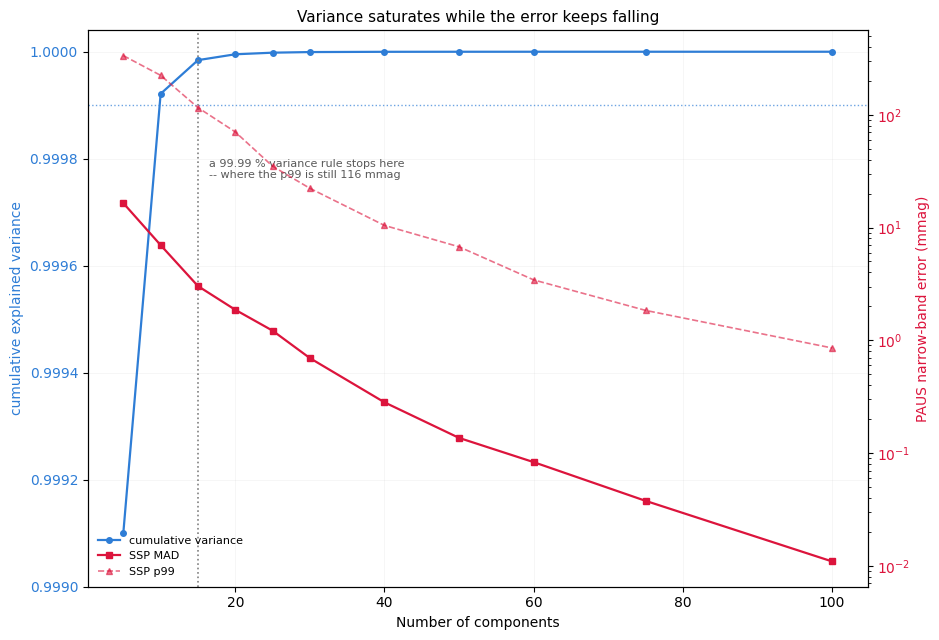

In [100]:
full = SpectralBasis.fit(wave, seds, 100, weight_scheme='inverse_std')
cumvar = np.cumsum(full.explained_variance_ratio)
op_paus = BandOperator(wave, paus, min_coverage=0.99)

scan = [5, 10, 15, 20, 25, 30, 40, 50, 60, 75, 100]
rows = []
for n in scan:
    b = full.truncate(n)
    rec = b.reconstruct(b.transform(seds), np.ones(len(seds)))
    s = summarise_mmag(mag_difference(seds, rec, op_paus))
    rows.append((n, cumvar[n - 1], np.median(s['mad']), np.median(s['p99'])))

print(f'{"N":>5}{"cumulative variance":>22}{"SSP MAD (mmag)":>17}{"p99 (mmag)":>13}')
print('-' * 57)
for n, cv, mad, p99 in rows:
    flag = '   <- "99.99% of the variance"' if n == 15 else ''
    print(f'{n:>5}{cv:>22.9f}{mad:>17.3f}{p99:>13.2f}{flag}')

N, CV, MAD, P99 = map(np.array, zip(*rows))
fig, ax = plt.subplots(figsize=(9.5, 6.5))
# Cumulative variance on a LINEAR axis, deliberately. Plotting 1 - CV on a log axis is
# also true, but it falls at the same rate as the error and so hides the very thing
# this figure exists to show: the number a variance threshold looks at stops moving.
ax.plot(N, CV, 'o-', color='#2E7DD6', lw=1.6, ms=4, label='cumulative variance')
ax.set_ylim(0.9990, 1.00004)
ax.axhline(0.9999, color='#2E7DD6', ls=':', lw=1.0, alpha=0.7)
ax.set_xlabel('Number of components')
ax.set_ylabel('cumulative explained variance', color='#2E7DD6')
ax.tick_params(axis='y', labelcolor='#2E7DD6')
ax2 = ax.twinx()
ax2.plot(N, MAD, 's-', color='crimson', lw=1.6, ms=4, label='SSP MAD')
ax2.plot(N, P99, '^--', color='crimson', lw=1.2, ms=4, alpha=0.6, label='SSP p99')
ax2.set_yscale('log'); ax2.set_ylabel('PAUS narrow-band error (mmag)', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')
ax.axvline(15, color='0.5', ls=':', lw=1.2)
ax.text(16.5, 0.99980, 'a 99.99 % variance rule stops here\n-- where the p99 is still 116 mmag',
        fontsize=8, color='0.35', va='top')
ax.set_title('Variance saturates while the error keeps falling', fontsize=11)
ax.grid(alpha=0.2, which='both', lw=0.4)
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8, frameon=False, loc='lower left')
fig.tight_layout(); plt.show()

At N = 15 the cumulative variance is 0.99998 — a number that reads like "done" — and the
99th-percentile narrow-band error is over 100 mmag. Variance saturates in the fourth
decimal place while the error falls three more orders of magnitude.

**Explained variance is not an error budget and must not be used as one.**

Choosing the count properly means plotting error against *bytes* and reading off the knee,
with galaxies rather than bare SSPs, and checking that derived statistics behave
monotonically. That is rung 07, `07_error_vs_bytes_budget.ipynb`, which reads the stored
experiment in `data/pca_experiments/`. The short answer is that N = 50 survives, but for a
reason measured in millimagnitudes rather than in decimal places of variance.

---

## 6. An open defect — reconstructions go negative

A truncated PCA is free to overshoot. Where the library is very faint, it does, and the
reconstruction goes below zero — which is not merely inaccurate but unphysical, and makes
a magnitude undefined rather than wrong.

In [96]:
print(f'{"N":>5}{"SSPs w/ any negative":>24}{"negative bins":>16}{"wavelength range":>20}')
print('-' * 65)
for n in (10, 25, 50, 100):
    b = full.truncate(n)
    rec = b.reconstruct(b.transform(seds), np.ones(len(seds)))
    neg = rec < 0
    if not neg.any():
        print(f'{n:>5}{"none":>24}'); continue
    wl = wave[neg.any(0)]
    frac_ssp = f'{neg.any(1).sum():,} / {len(seds):,}'
    print(f'{n:>5}{frac_ssp:>24}{neg.mean() * 100:>14.2f} %'
          f'{f"{wl.min():.0f} - {wl.max():.0f} A":>20}')

# The direction is the uncomfortable part: the scheme that wins every photometric
# metric loses this one.
for scheme in ('uniform', 'inverse_std'):
    b = SpectralBasis.fit(wave, seds, 50, weight_scheme=scheme)
    rec = b.reconstruct(b.transform(seds), np.ones(len(seds)))
    print(f'\nN = 50, {scheme:<12} negative bins: {(rec < 0).mean() * 100:5.2f} %  '
          f'({(rec < 0).any(1).sum():,} of {len(seds):,} SSPs affected)')

    N    SSPs w/ any negative   negative bins    wavelength range
-----------------------------------------------------------------
   10             705 / 1,200          3.04 %        805 - 4870 A
   25             649 / 1,200          2.91 %        805 - 4310 A
   50             592 / 1,200          1.92 %        805 - 3830 A
  100             522 / 1,200          0.94 %        805 - 2865 A

N = 50, uniform      negative bins:  1.12 %  (558 of 1,200 SSPs affected)

N = 50, inverse_std  negative bins:  1.92 %  (592 of 1,200 SSPs affected)


The cause is the one §4.1 established: these are not a separate defect. A negative bin is
what a fractional error greater than 100 % looks like, and it appears exactly where the
library is faintest. Two further things follow.

**The numbers here are larger than the ones in `documents/error_vs_bytes.md` §7, and they
are not the same measurement.** That study reports 33.8 % of SSPs affected at N = 50; this
notebook finds roughly half. The difference is the grid: the study fits on the R = 300 grid
running from 1048 Å, while this section uses the native grid from 805 Å, which includes the
faintest far-UV where almost all the negatives live. Neither number is wrong — quoting one
for the other would be.

**`inverse_std` is worse than `uniform` here**, the reverse of every photometric metric.
Weighting away from absolute flux is exactly what lets the fit overshoot where the library
is faint. That is a real trade-off rather than a bug, and it is unresolved: the fix is a
non-negative decomposition, which is a different family of basis altogether.

---

## 7. Which populations reconstruct well, and which do not

§4.1 explained the far-UV in terms of *brightness*. Since brightness at a given wavelength
is set by age and metallicity, that prediction can be turned around: reconstruction quality
should be an orderly function of the two parameters the library is built on. It is.

Two metrics, because they answer different questions and do not agree. The **fractional
flux error** is a statement about the spectrum, and inherits the far-UV problem. The
**broadband error** is a statement about what the science actually measures, and at
rest-frame optical wavelengths the far-UV contributes essentially nothing.

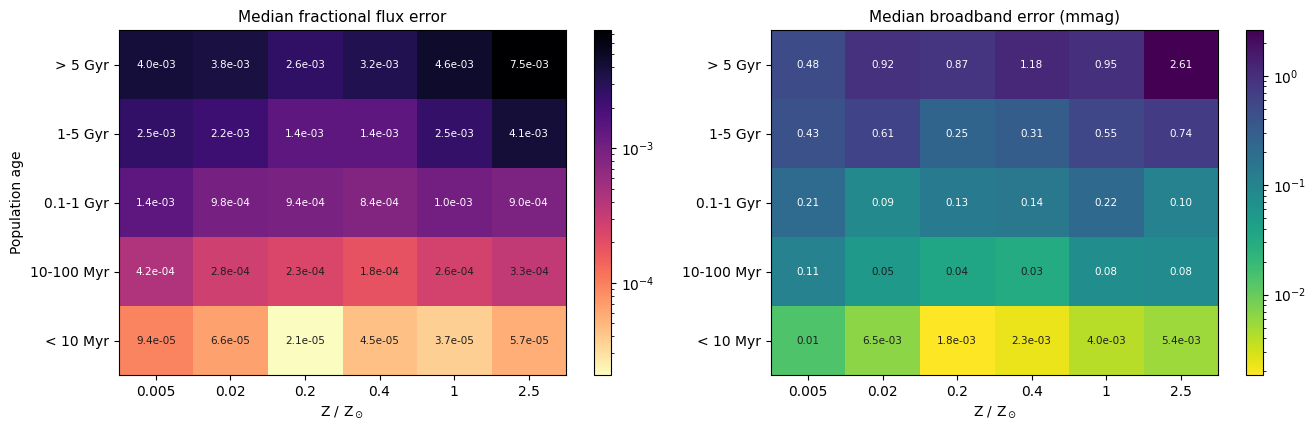

In [97]:
from matplotlib.colors import LogNorm

err_flux = np.median(fracerr, axis=1)                                  # per SSP
err_mag  = np.nanmedian(np.abs(mag_difference(seds, rec50, op_bb)), axis=1)

# Bin onto the (age, Z) grid. Ages are binned in log; metallicity is already discrete.
AGE_EDGES = np.array([0.0, 0.01, 0.1, 1.0, 5.0, 14.0])
AGE_LABEL = ['< 10 Myr', '10-100 Myr', '0.1-1 Gyr', '1-5 Gyr', '> 5 Gyr']
Z_VALUES  = np.unique(logzsol)

def grid_median(values):
    out = np.full((len(AGE_LABEL), len(Z_VALUES)), np.nan)
    for i in range(len(AGE_LABEL)):
        for j, z in enumerate(Z_VALUES):
            m = (age >= AGE_EDGES[i]) & (age < AGE_EDGES[i + 1]) & np.isclose(logzsol, z)
            if m.any():
                out[i, j] = np.median(values[m])
    return out

maps = [('Median fractional flux error', grid_median(err_flux), 'magma_r'),
        ('Median broadband error (mmag)', grid_median(err_mag), 'viridis_r')]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))
for ax, (title, M, cmap) in zip(axes, maps):
    im = ax.imshow(M, cmap=cmap, aspect='auto', origin='lower',
                   norm=LogNorm(vmin=np.nanmin(M), vmax=np.nanmax(M)))
    ax.set_xticks(range(len(Z_VALUES)))
    ax.set_xticklabels([f'{10 ** z:g}' for z in Z_VALUES])
    ax.set_yticks(range(len(AGE_LABEL))); ax.set_yticklabels(AGE_LABEL)
    ax.set_xlabel('Z / Z$_\\odot$'); ax.set_title(title, fontsize=11)
    # Separate colour bars on purpose: the two quantities differ by orders of magnitude
    # and a shared scale would flatten whichever has the smaller range.
    fig.colorbar(im, ax=ax)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            val = M[i, j]
            # Both maps use a log colour scale, so the light/dark decision has to be
            # made in log space too; a percentile threshold left mid-tone cells with
            # dark text on a dark ground.
            mid = np.sqrt(np.nanmin(M) * np.nanmax(M))
            ax.text(j, i, f'{val:.1e}' if val < 0.01 else f'{val:.2f}',
                    ha='center', va='center', fontsize=7.5,
                    color='white' if val > mid else '0.12')
axes[0].set_ylabel('Population age')
fig.tight_layout(); plt.show()

In [98]:
# The library has duplicate rows: below a couple of Myr the requested age grid is finer
# than the one BC03 itself samples, so the interpolation returns the same spectrum
# repeatedly. Ranking those against each other is meaningless -- they are the same
# spectrum with different labels -- so the ranking runs over distinct rows only.
_, first_of_kind = np.unique(seds, axis=0, return_index=True)
distinct = np.sort(first_of_kind)
print(f'library rows: {len(seds):,}   distinct spectra: {len(distinct):,}   '
      f'duplicates: {len(seds) - len(distinct):,}')
print(f'all duplication is at ages below '
      f'{age[np.setdiff1d(np.arange(len(seds)), distinct)].max() * 1e3:.1f} Myr')

def ranking(values, label, unit, n=5):
    order = distinct[np.argsort(values[distinct])]
    print(f'\n{label}')
    print(f'{"":6}{"age":>11}{"Z/Zsun":>9}{"frac error":>13}{"broadband":>12}')
    for tag, idx in (('BEST', order[:n]), ('WORST', order[::-1][:n])):
        for rank, k in enumerate(idx):
            head = tag if rank == 0 else ''
            a = f'{age[k] * 1e3:.2f} Myr' if age[k] < 0.1 else f'{age[k]:.2f} Gyr'
            print(f'{head:<6}{a:>11}{10 ** logzsol[k]:>9.3g}'
                  f'{err_flux[k]:>13.2e}{err_mag[k]:>10.3f} mmag')

ranking(err_flux, 'Ranked by median fractional flux error', 'frac')
ranking(err_mag,  'Ranked by median broadband error',       'mmag')

ef, em = err_flux[distinct], err_mag[distinct]
print(f'\nspread across the distinct library, at fixed N = {basis.n_components}:')
print(f'  fractional error   {ef.min():.2e} to {ef.max():.2e}   ({ef.max() / ef.min():,.0f}x)')
print(f'  broadband error    {em.min():.4f} to {em.max():.3f} mmag   ({em.max() / em.min():,.0f}x)')

library rows: 1,200   distinct spectra: 997   duplicates: 203
all duplication is at ages below 2.3 Myr

Ranked by median fractional flux error
              age   Z/Zsun   frac error   broadband
BEST     3.33 Myr    0.005     1.39e-05     0.003 mmag
         0.37 Myr      2.5     1.57e-05     0.003 mmag
         3.54 Myr    0.005     1.68e-05     0.004 mmag
         4.23 Myr    0.005     1.79e-05     0.005 mmag
         0.10 Myr      0.2     2.07e-05     0.002 mmag
WORST    7.56 Gyr      2.5     7.93e-03     3.089 mmag
        12.16 Gyr      2.5     7.81e-03     2.167 mmag
        12.91 Gyr      2.5     7.79e-03     2.003 mmag
        13.70 Gyr      2.5     7.73e-03     1.842 mmag
         7.12 Gyr      2.5     7.61e-03     3.057 mmag

Ranked by median broadband error
              age   Z/Zsun   frac error   broadband
BEST     0.10 Myr      0.2     2.07e-05     0.002 mmag
         1.63 Myr      2.5     6.01e-05     0.002 mmag
         6.80 Myr        1     3.90e-05     0.002 mmag
    

Two things to take from the maps.

**Age dominates, and it is monotonic.** Reading down any metallicity column, the median
fractional error rises by 40 to 130 times from the youngest bin to the oldest; across
individual spectra the full spread is the 571x printed above. Every column runs the same
way, in exactly the direction §4.1 predicts: old populations are the faint ones in the UV.

**Metallicity is secondary in flux terms but sharply worse in the broadband.** At old ages
the metal-rich corner is several times worse than the metal-poor one in millimagnitudes —
far more than the fractional-error map suggests — because high metallicity moves absorption
features into the optical, where the broadband filters actually are. The two rankings are
therefore *not* the same list, which is the reason to show both.

**A property of the training set, found while building this table.** 203 of the 1200 rows
are exact duplicates — only 997 spectra are distinct. Below about 2 Myr the age grid the
library was generated on is finer than the ages BC03 itself tabulates, so the interpolation
returns the same spectrum several times over. Those rows carry extra weight in the fit,
which tilts it very slightly towards the youngest populations. Removing them is *not* an
improvement: it buys 8 % in the old far-UV and costs 31 % in broadband accuracy, so the
duplicates are left in and the ranking above simply skips them.

That corner matters. Old, metal-rich populations are what dominate the light of red
galaxies, which is where the colour bias in `documents/validation_by_colour.md` was
measured. This basis is at its least accurate exactly there — not by enough to explain that
bias (`documents/error_vs_bytes.md` §5 shows the basis contributes 0.9 % of it), but it is
the right place to look first when a red-galaxy number seems off.

---

## 8. Which basis the rest of the project uses

There are **two** bases in this repository, and it is easy to assume there is one.

| | grid | range | weighting | used by |
|---|---|---|---|---|
| `data/pca_results_bc03.npz` | native, 831 bins | 805-29950 A | `inverse_std` | every downstream notebook, the batch processor, and the in-code C path |
| `data/pca_experiments/bc03_R300_basis_*.npz` | log-lambda, 934 bins | 1048-23552 A | five schemes | the error-vs-bytes experiment only |

The committed file predates the weighting module and stores its preprocessing as a
`norm` dict of per-wavelength mean and standard deviation rather than as a named scheme.
Those are the same thing, which is worth checking rather than believing.

In [99]:
committed = np.load(PROJECT_ROOT / 'data' / 'pca_results_bc03.npz', allow_pickle=True)
norm = committed['norm'].item()

assert np.allclose(norm['mean'], seds.mean(axis=0)), 'stored mean is not the library mean'
assert np.allclose(norm['std'],  seds.std(axis=0)),  'stored std is not the library std'

w_std, _ = build_weights('inverse_std', seds, wave)
ratio = w_std * norm['std']
assert np.allclose(ratio, ratio[0]), 'inverse_std is not proportional to 1/std'

print(f'committed basis : {committed["components"].shape[0]} components x '
      f'{committed["wave"].size} bins, {committed["wave"].min():.0f}-'
      f'{committed["wave"].max():.0f} A')
print(f'its `norm` is the library column mean and std   -> checked')
print(f'`inverse_std` = 1/std up to one constant  -> checked')
print(f'   (that constant is {ratio[0]:.3g}: build_weights rescales so the geometric')
print(f'    mean weight is 1, which is cosmetic -- see below)')
print('\nAn overall scalar on the weights cancels exactly between fit and reconstruct,')
print('so the committed basis and an `inverse_std` fit are the same scheme.')

committed basis : 50 components x 831 bins, 805-29950 A
its `norm` is the library column mean and std   -> checked
`inverse_std` = 1/std up to one constant  -> checked
   (that constant is 1.3e+31: build_weights rescales so the geometric
    mean weight is 1, which is cosmetic -- see below)

An overall scalar on the weights cancels exactly between fit and reconstruct,
so the committed basis and an `inverse_std` fit are the same scheme.


---

## What to take away

1. **A galaxy is the mass-weighted sum of SSPs**, and every design decision here exists to
   keep that sum exact. The basis is linear in flux, the weights depend on wavelength only,
   and the mass is stored alongside the coefficients.
2. **The grid is a choice, and the library's own grid is a poor one.** A constant-R grid
   stops the finely-sampled optical dominating the fit by accident, and buys 1.4x in
   narrow-band accuracy for free.
3. **Weighting decides where the fit spends its effort.** The forbidden schemes are
   forbidden because they fail *silently* — per-SSP checks pass and only composed galaxies
   are wrong.
4. **Explained variance is not an error budget.** 99.99 % of the variance leaves a
   100 mmag tail. Choose N from an error curve.
5. **The basis is accurate where the library is bright.** The far-UV of old populations is
   the one place it is not, because PCA minimises absolute error and an old population is
   $10^5$ times fainter there than a young one. No wavelength-only weight can separate
   them, and the negative fluxes are the same phenomenon.
6. **Quality is an orderly function of age and metallicity** — worst for old, metal-rich
   populations, which is where red-galaxy light comes from.

**Next rung:** `04_galaxy_sed_explorer.ipynb` uses this basis on real galaxies;
`07_error_vs_bytes_budget.ipynb` turns §5 into an actual component-count decision.